### **1. Isotropic Covariance Matrix**

In [130]:
import numpy as np
import matplotlib.pyplot as plt
from src.distributions import gaussian

In [131]:
rng = np.random.default_rng(42) # fixing seed 42

# hand picked mu and sigma as 1
n = 1000
mu = np.array([2, 4])
sigma = 1

x1 = gaussian(mu[0], sigma, n, rng)
x2 = gaussian(mu[1], sigma, n, rng)

X = np.column_stack((x1, x2))

In [132]:
print("Shape:", X.shape)
print("Target mean:", mu)
print("Sample mean:", X.mean(axis=0))

Shape: (1000, 2)
Target mean: [2 4]
Sample mean: [1.98413382 3.9676051 ]


In [133]:
X[:5]

array([[3.48320678, 4.5753355 ],
       [1.66908592, 2.10384994],
       [2.78377812, 2.4803518 ],
       [2.43138215, 2.8040629 ],
       [2.68134042, 5.4946898 ]])

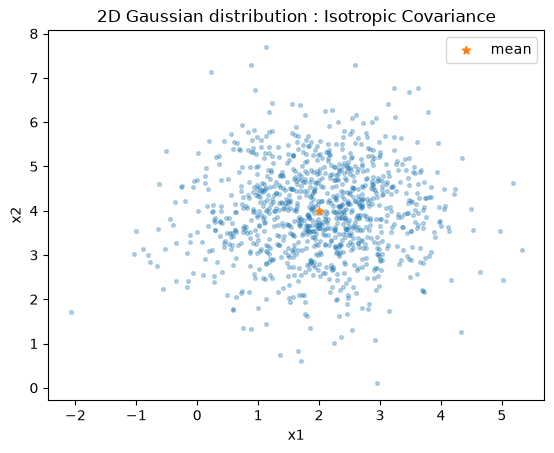

In [134]:
plt.scatter(X[:, 0], X[:, 1], alpha=0.3, s=7)
plt.scatter(mu[0], mu[1], marker="*", label="mean")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("2D Gaussian distribution : Isotropic Covariance")
plt.legend()
plt.show()

In [135]:
# calculating co-variance matrix via hand

mu_hat = np.array([X[:, 0].mean(), X[:, 1].mean()])
X_centered = X - mu_hat

C_hand = (1/n) * X_centered.T @ X_centered
C_hand

array([[1.03696445, 0.04630032],
       [0.04630032, 1.07409672]])

In [136]:
# computing the covariance matrix using numpy

C = np.cov(X, rowvar=False)
C

array([[1.03800245, 0.04634667],
       [0.04634667, 1.07517189]])

In [137]:
# computing the eigenvalues and eigenvectors

eigenvalues, eigenvectors = np.linalg.eigh(C)

# order them in descending
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

print("Eigen values:", eigenvalues)
print("Eigen vectors:\n", eigenvectors)


Eigen values: [1.10652119 1.00665316]
Eigen vectors:
 [[ 0.56027422 -0.82830719]
 [ 0.82830719  0.56027422]]


In [148]:
# forming a meshgrid

# [mu - 4.sigma to mu + 4.sigma]
x = np.linspace(x1.mean() - 4 * x1.std(), x1.mean() + 4 * x1.std(), 200)
y = np.linspace(x2.mean() - 4 * x2.std(), x2.mean() + 4 * x2.std(), 200)

x_grid, y_grid = np.meshgrid(x, y)

C_inv = np.linalg.inv(C)
q_grid = np.zeros(x_grid.shape)
mean = mu_hat.reshape(2, 1)

for i in range(x_grid.shape[0]):
    for j in range(x_grid.shape[1]):
        point = np.array([
            [x_grid[i, j]],
            [y_grid[i, j]]
        ])

        deviation = point - mean

        q_grid[i, j] = (deviation.T @ C_inv @ deviation).item()


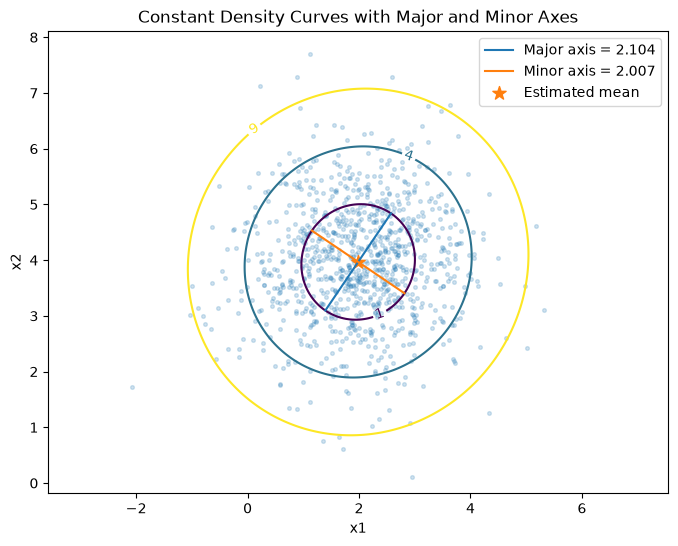

In [154]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.2, s=7)

contours = plt.contour(x_grid, y_grid, q_grid, levels=[1, 4, 9])
plt.clabel(contours)

major_vector = np.sqrt(eigenvalues[0]) * eigenvectors[:, 0]
minor_vector = np.sqrt(eigenvalues[1]) * eigenvectors[:, 1]

major_axis_length = 2 * np.sqrt(eigenvalues[0])
minor_axis_length = 2 * np.sqrt(eigenvalues[1])

plt.plot(
    [mu_hat[0] - major_vector[0], mu_hat[0] + major_vector[0]],
    [mu_hat[1] - major_vector[1], mu_hat[1] + major_vector[1]],
    label=f"Major axis = {major_axis_length:.3f}"
)

plt.plot(
    [mu_hat[0] - minor_vector[0], mu_hat[0] + minor_vector[0]],
    [mu_hat[1] - minor_vector[1], mu_hat[1] + minor_vector[1]],
    label=f"Minor axis = {minor_axis_length:.3f}"
)

plt.scatter(mu_hat[0], mu_hat[1], marker="*", s=100, label="Estimated mean")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Constant Density Curves with Major and Minor Axes")
plt.legend()
plt.axis("equal")
plt.show()

### **Diagonal Covariance Matrix**